In [65]:
!pip install seaborn

# Carregando a base de dados

In [205]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LinearRegression                           
from sklearn.metrics import mean_absolute_error, r2_score 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [22]:
ibovespa = pd.read_csv(r"../data/raw/Dados Históricos - Ibovespa.csv", sep=',')
ibovespa.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,19.02.2026,188.534,186.020,188.687,185.928,"9,24B","1,35%"
1,18.02.2026,186.016,186.464,187.657,185.001,"7,79B","-0,24%"
2,13.02.2026,186.464,187.766,187.766,183.662,"11,59B","-0,69%"
3,12.02.2026,187.766,189.694,189.990,186.959,"12,36B","-1,02%"
4,11.02.2026,189.699,185.936,190.561,185.936,"11,64B","2,03%"


In [23]:
# Quais os tipos informações compõe o banco de dados (base original)
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Data      534 non-null    str    
 1   Último    534 non-null    float64
 2   Abertura  534 non-null    float64
 3   Máxima    534 non-null    float64
 4   Mínima    534 non-null    float64
 5   Vol.      534 non-null    str    
 6   Var%      534 non-null    str    
dtypes: float64(4), str(3)
memory usage: 29.3 KB


# EDA - Análise Exploratória de Dados

In [24]:
# renomeando as colunas
ibovespa.rename(columns={'Data': 'data', 'Abertura': 'abertura', 'Máxima': 'maxima', 'Mínima': 'minima', 'Último': 'fechamento', 'Vol.': 'volume', "Var%": "variacao_percentual"}, inplace=True)
ibovespa["volume"] = (ibovespa["volume"].str.replace("B", "").str.replace("M", "").str.replace(",", ".").astype(float))
ibovespa["variacao_percentual"] = (ibovespa["variacao_percentual"].str.replace("%", "").str.replace(",", ".").astype(float))


ibovespa.head()

,data,fechamento,abertura,maxima,minima,volume,variacao_percentual
0,19.02.2026,188.534,186.020,188.687,185.928,9.24,1.35
1,18.02.2026,186.016,186.464,187.657,185.001,7.79,-0.24
2,13.02.2026,186.464,187.766,187.766,183.662,11.59,-0.69
3,12.02.2026,187.766,189.694,189.990,186.959,12.36,-1.02
4,11.02.2026,189.699,185.936,190.561,185.936,11.64,2.03


In [25]:
ibovespa.describe().T

,count,mean,std,min,25%,50%,75%,max
fechamento,534.0,135.754279,14.000180,118.533,127.22750,131.1685,138.87975,189.699
abertura,534.0,135.653060,13.813322,118.534,127.22300,131.1680,138.85225,189.694
maxima,534.0,136.561036,14.069473,119.451,127.87125,131.8675,139.39650,190.561
minima,534.0,134.888457,13.746830,118.223,126.44875,130.4240,137.98750,186.959
volume,534.0,9.456798,2.375334,3.310,7.97250,9.1950,10.60500,24.870
variacao_percentual,534.0,0.067959,0.916199,-4.310,-0.44750,0.0500,0.59000,3.330


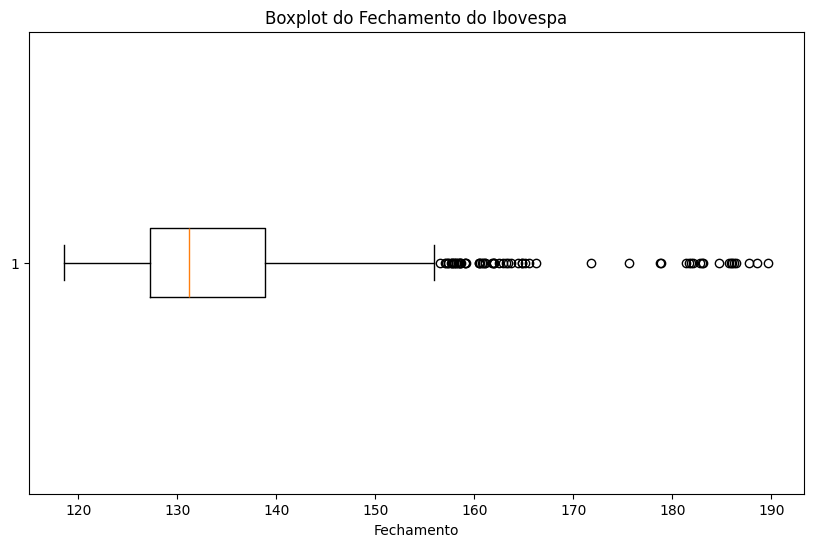

In [26]:
plt.figure(figsize=(10, 6))
plt.boxplot(ibovespa['fechamento'], vert=False)
plt.title('Boxplot do Fechamento do Ibovespa')
plt.xlabel('Fechamento')
plt.show()

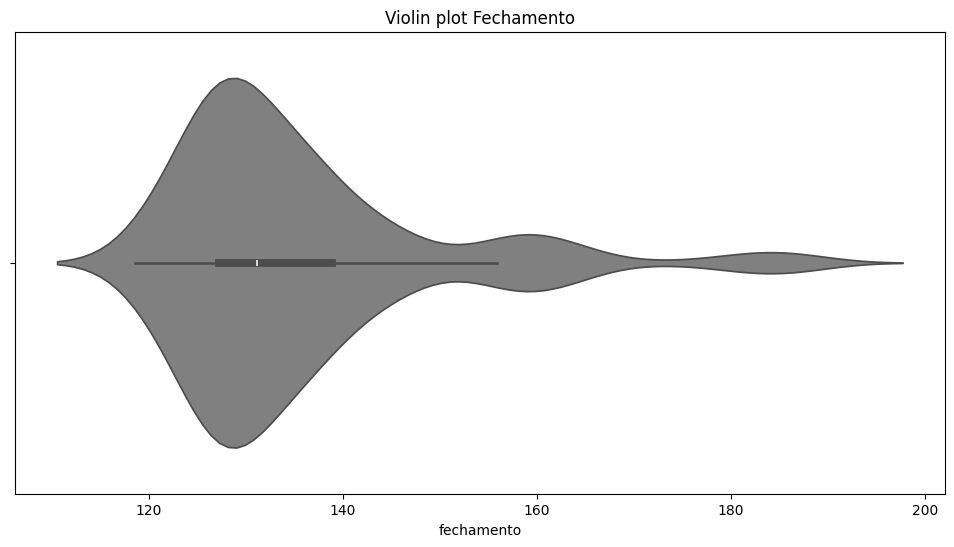

In [72]:
#Criando o subplot do boxplot, para configurarmos o tamanho
fig, axes = plt.subplots(figsize=(12,6))
sns.violinplot(x="fechamento", data=ibovespa, color="gray")
axes.set_title('Violin plot Fechamento')
plt.show()

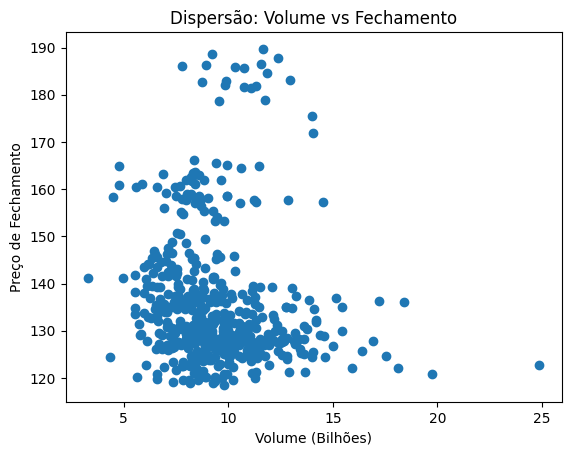

In [27]:
ibovespa["data"] = pd.to_datetime(ibovespa["data"], format="%d.%m.%Y")

plt.figure()
plt.scatter(ibovespa["volume"], ibovespa["fechamento"])

plt.xlabel("Volume (Bilhões)")
plt.ylabel("Preço de Fechamento")
plt.title("Dispersão: Volume vs Fechamento")

plt.show()


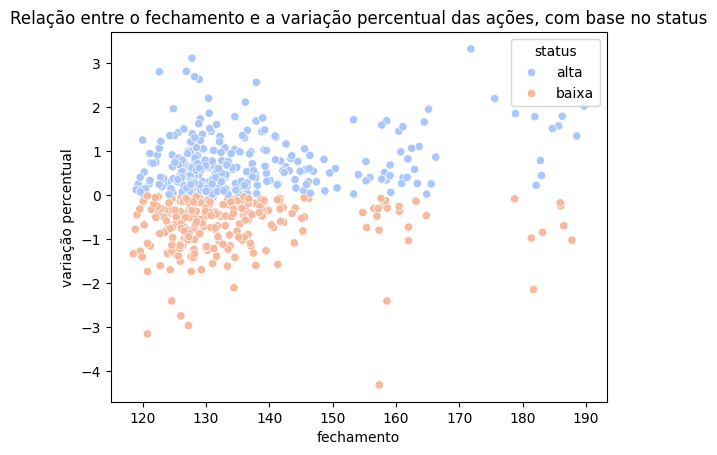

In [77]:

#Vamos verificar ambas coluna gerando um gráfico de dispersão
sns.scatterplot(x='fechamento', y='variacao_percentual', hue='status', data=ibovespa, palette='coolwarm')
plt.xlabel('fechamento')
plt.ylabel('variação percentual')
plt.title('Relação entre o fechamento e a variação percentual das ações, com base no status')
plt.show()

In [ ]:
# Transformando a coluna Data de objeto para data
ibovespa["data"] = pd.to_datetime(ibovespa["data"])
ibovespa.head()

,data,fechamento,abertura,maxima,minima,volume,variacao_percentual
0,2026-02-19,188.534,186.020,188.687,185.928,9.24,1.35
1,2026-02-18,186.016,186.464,187.657,185.001,7.79,-0.24
2,2026-02-13,186.464,187.766,187.766,183.662,11.59,-0.69
3,2026-02-12,187.766,189.694,189.990,186.959,12.36,-1.02
4,2026-02-11,189.699,185.936,190.561,185.936,11.64,2.03


In [31]:
# Quantidade de dados nulos por coluna
ibovespa.isnull().sum()

data                   0
fechamento             0
abertura               0
maxima                 0
minima                 0
volume                 0
variacao_percentual    0
dtype: int64

In [38]:
# Criando uma coluna Estratégia de engenharia de atributos se fechou em alta ou em baixa
ibovespa['status'] = ibovespa.apply(lambda row: 'alta' if row['variacao_percentual'] > 0 else 'baixa', axis=1)
ibovespa.head()

,data,fechamento,abertura,maxima,minima,volume,variacao_percentual,status
0,2026-02-19,188.534,186.020,188.687,185.928,9.24,1.35,alta
1,2026-02-18,186.016,186.464,187.657,185.001,7.79,-0.24,baixa
2,2026-02-13,186.464,187.766,187.766,183.662,11.59,-0.69,baixa
3,2026-02-12,187.766,189.694,189.990,186.959,12.36,-1.02,baixa
4,2026-02-11,189.699,185.936,190.561,185.936,11.64,2.03,alta


In [34]:
# Validando a saída final da base
ibovespa.info()

<class 'pandas.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 534 non-null    datetime64[us]
 1   fechamento           534 non-null    float64       
 2   abertura             534 non-null    float64       
 3   maxima               534 non-null    float64       
 4   minima               534 non-null    float64       
 5   volume               534 non-null    float64       
 6   variacao_percentual  534 non-null    float64       
 7   status               534 non-null    str           
dtypes: datetime64[us](1), float64(6), str(1)
memory usage: 33.5 KB


In [35]:
# Considerando apenas as colunas relevantes
ibovespa_final = ibovespa[['data', 'abertura', 'maxima', 'minima', 'fechamento', 'variacao_percentual', 'status']]

In [36]:
# Salvando dataframe final em csv
ibovespa_final.to_csv('../data/trusted/ibovespa_historico.csv', index=False, sep = ';')

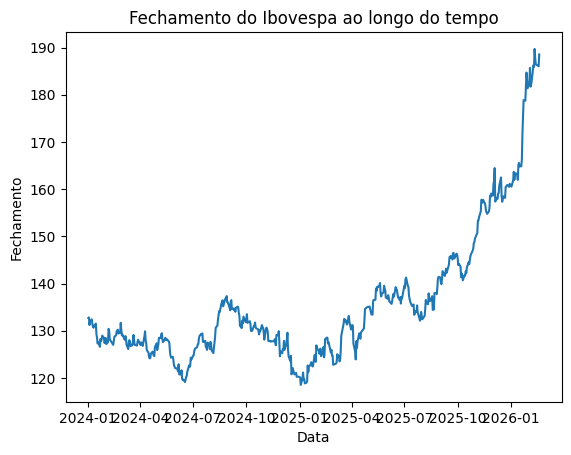

In [44]:
plt.plot(ibovespa['data'], ibovespa['fechamento'])
plt.xlabel('Data')
plt.ylabel('Fechamento')
plt.title('Fechamento do Ibovespa ao longo do tempo')
plt.show()

## Testando o modelo Scikit-Learn  ✅

In [61]:
x = ibovespa_final.drop(columns=['status', 'data'])
y = ibovespa_final['status']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [62]:
knn = KNeighborsClassifier(n_neighbors=3)

In [63]:
knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [64]:
accuracy = knn.score(x_test, y_test) 
print("Acurácia: {:.2f}%".format(round(accuracy,2) * 100))

Acurácia: 86.00%


# Testando o modelo Regressao Linear Minimo Escalado ❌

In [101]:
# Instanciando
le = LabelEncoder()
ibovespa_final["status_encoded"] = le.fit_transform(ibovespa_final["status"])

In [102]:
x = ibovespa_final.drop(columns=['status', 'data'])
y = ibovespa_final['status_encoded']

In [103]:
ibovespa_final.head()

,data,abertura,maxima,minima,fechamento,variacao_percentual,status,status_encoded
0,2026-02-19,186.020,188.687,185.928,188.534,1.35,alta,0
1,2026-02-18,186.464,187.657,185.001,186.016,-0.24,baixa,1
2,2026-02-13,187.766,187.766,183.662,186.464,-0.69,baixa,1
3,2026-02-12,189.694,189.990,186.959,187.766,-1.02,baixa,1
4,2026-02-11,185.936,190.561,185.936,189.699,2.03,alta,0


In [104]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

scaler = MinMaxScaler()

scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [105]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [106]:
# Fazendo as previsões
y_pred = model.predict(x_test_scaled)

In [107]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('MAE',MAE)
print('r²',r2)

MAE 1.7556063925719666e-16
r² 1.0


# Testando o modelo Regressao Linear ❌

In [120]:
ibovespa_final.head()

,data,abertura,maxima,minima,fechamento,variacao_percentual,status,status_encoded
0,2026-02-19,186.020,188.687,185.928,188.534,1.35,alta,0
1,2026-02-18,186.464,187.657,185.001,186.016,-0.24,baixa,1
2,2026-02-13,187.766,187.766,183.662,186.464,-0.69,baixa,1
3,2026-02-12,189.694,189.990,186.959,187.766,-1.02,baixa,1
4,2026-02-11,185.936,190.561,185.936,189.699,2.03,alta,0


In [129]:
x = ibovespa_final.drop(columns=['status', 'data', 'status_encoded'])
y = ibovespa_final['status_encoded']

In [134]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=101)

In [135]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [136]:
y_pred = model.predict(x_test)
r_sq = model.score(x, y)

print('Coeficiente de Determinação (R²):', r_sq)

Coeficiente de Determinação (R²): 0.580206616177608


In [137]:
print('Intercepto:', model.intercept_)

Intercepto: 0.49190656760651824


# Testando o modelo Random Forest Regressor ⚠️

In [155]:
x = ibovespa_final.drop(columns=['status', 'data', 'status_encoded', 'variacao_percentual'])
y = ibovespa_final['status_encoded']

In [156]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [157]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=7))
])

In [158]:
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")
print("\nRelatório:")
print(classification_report(y_test, y_pred))

Acurácia: 0.8131

Relatório:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83        62
           1       0.74      0.87      0.80        45

    accuracy                           0.81       107
   macro avg       0.81      0.82      0.81       107
weighted avg       0.82      0.81      0.81       107

